# Аналіз графів

## Вступ до аналізу графів

Аналіз графів - це спеціалізована область інтелектуального аналізу даних, яка зосереджується на пошуку патернів, структур та знань у графових даних. На відміну від традиційного інтелектуального аналізу даних, який працює з табличними даними, аналіз графів має справу з сутностями (вузлами) та їх зв'язками (ребрами).

Аналіз графів має застосування в:
- Аналізі соціальних мереж
- Аналізі біологічних мереж
- Аналізі веб-даних та системах рекомендацій
- Транспортних мережах
- Виявленні фінансового шахрайства
- Кібербезпеці

## Основи теорії графів

Перед тим, як зануритися в алгоритми аналізу графів, давайте згадаємо фундаментальні концепції, які формують основу теорії графів.

### Основні компоненти графа

**Граф (G)**: Математична структура, що складається з:
- **Вершин (V)**: Також називаються вузлами, вони представляють сутності в системі
- **Ребер (E)**: Також називаються зв'язками, вони представляють зв'язки між сутностями

Граф формально визначається як $G = (V, E)$, де $V$ - множина вершин, а $E$ - множина ребер.

### Типи графів

**1. Орієнтовані vs Неорієнтовані графи**
- **Неорієнтований граф**: Ребра не мають напрямку; якщо є ребро між A та B, зв'язок є двонаправленим
- **Орієнтований граф (Диграф)**: Ребра мають напрямок; ребро від A до B відрізняється від ребра від B до A

**2. Зважені vs Незважені графи**
- **Незважений граф**: Всі ребра мають однакову важливість
- **Зважений граф**: Ребра мають пов'язані ваги, що представляють силу, вартість або важливість зв'язку

### Важливі властивості графів

**Степінь**: Кількість ребер, інцидентних вершині
- В орієнтованих графах: вхідний степінь (вхідні ребра) та вихідний степінь (вихідні ребра)

**Шлях**: Послідовність вершин, де кожна сусідня пара з'єднана ребром

**Цикл**: Шлях, який починається та закінчується в тій самій вершині

**Зв'язність**: 
- **Зв'язний граф**: Є шлях між будь-якими двома вершинами
- **Сильно зв'язний**: В орієнтованих графах існує шлях між будь-якими двома вершинами

**Підграф**: Граф, утворений підмножиною вершин та ребер з оригінального графа

### Представлення графів

![Matrix D](images/13.0-matrix-d.png)

[Джерело зображення](https://uk.wikipedia.org/wiki/%D0%A1%D1%82%D0%B5%D0%BF%D0%B5%D0%BD%D0%B5%D0%B2%D0%B0_%D0%BC%D0%B0%D1%82%D1%80%D0%B8%D1%86%D1%8F)

![Matrix A](images/13.1-matrix-a.png)

[Джерело зображення](https://uk.wikipedia.org/wiki/%D0%9C%D0%B0%D1%82%D1%80%D0%B8%D1%86%D1%8F_%D1%81%D1%83%D0%BC%D1%96%D0%B6%D0%BD%D0%BE%D1%81%D1%82%D1%96)

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

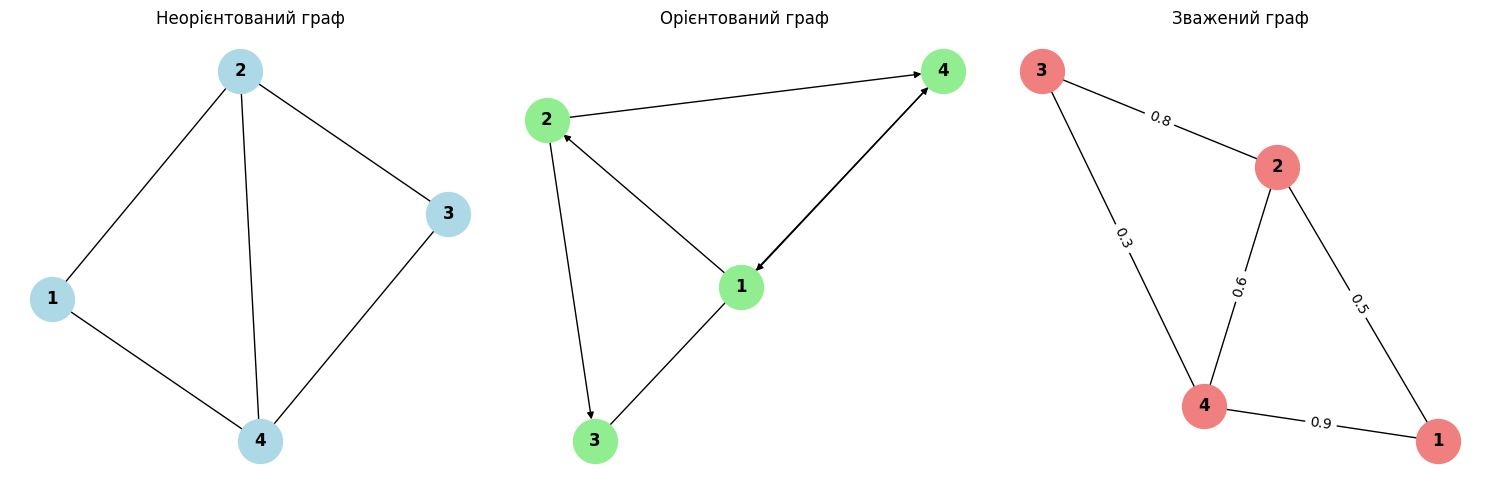

Властивості графів:
Неорієнтований граф - Вершини: 4, Ребра: 5
Орієнтований граф - Вершини: 4, Ребра: 5
Зважений граф - Вершини: 4, Ребра: 5


In [2]:
G_undirected = nx.Graph()
G_undirected.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1), (2, 4)])

G_directed = nx.DiGraph()
G_directed.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1), (2, 4)])

G_weighted = nx.Graph()
G_weighted.add_weighted_edges_from([(1, 2, 0.5), (2, 3, 0.8), (3, 4, 0.3), (4, 1, 0.9), (2, 4, 0.6)])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nx.draw(G_undirected, ax=axes[0], with_labels=True, node_color='lightblue', 
        node_size=1000, font_size=12, font_weight='bold')
axes[0].set_title('Неорієнтований граф')

nx.draw(G_directed, ax=axes[1], with_labels=True, node_color='lightgreen', 
        node_size=1000, font_size=12, font_weight='bold', arrows=True)
axes[1].set_title('Орієнтований граф')

pos = nx.spring_layout(G_weighted)
nx.draw(G_weighted, pos, ax=axes[2], with_labels=True, node_color='lightcoral', 
        node_size=1000, font_size=12, font_weight='bold')
edge_labels = nx.get_edge_attributes(G_weighted, 'weight')
nx.draw_networkx_edge_labels(G_weighted, pos, edge_labels, ax=axes[2])
axes[2].set_title('Зважений граф')

plt.tight_layout()
plt.show()

print("Властивості графів:")
print(f"Неорієнтований граф - Вершини: {G_undirected.number_of_nodes()}, Ребра: {G_undirected.number_of_edges()}")
print(f"Орієнтований граф - Вершини: {G_directed.number_of_nodes()}, Ребра: {G_directed.number_of_edges()}")
print(f"Зважений граф - Вершини: {G_weighted.number_of_nodes()}, Ребра: {G_weighted.number_of_edges()}")

In [3]:
social_network = nx.DiGraph()

people = ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace', 'Henry', 'Ivy', 'Jack']
social_network.add_nodes_from(people)

relationships = [
    ('Alice', 'Bob'), ('Alice', 'Charlie'), ('Alice', 'Diana'),
    ('Bob', 'Alice'), ('Bob', 'Charlie'), ('Bob', 'Eve'),
    ('Charlie', 'Alice'), ('Charlie', 'Bob'), ('Charlie', 'Diana'), ('Charlie', 'Eve'),
    ('Diana', 'Alice'), ('Diana', 'Charlie'), ('Diana', 'Frank'),
    ('Eve', 'Bob'), ('Eve', 'Charlie'), ('Eve', 'Grace'),
    ('Frank', 'Diana'), ('Frank', 'Grace'), ('Frank', 'Henry'),
    ('Grace', 'Eve'), ('Grace', 'Frank'), ('Grace', 'Ivy'),
    ('Henry', 'Frank'), ('Henry', 'Grace'), ('Henry', 'Jack'),
    ('Ivy', 'Grace'), ('Ivy', 'Henry'), ('Ivy', 'Jack'),
    ('Jack', 'Henry'), ('Jack', 'Ivy')
]

social_network.add_edges_from(relationships)

edge_weights = {
    ('Alice', 'Bob'): 0.9, ('Alice', 'Charlie'): 0.8, ('Alice', 'Diana'): 0.7,
    ('Bob', 'Alice'): 0.9, ('Bob', 'Charlie'): 0.6, ('Bob', 'Eve'): 0.5,
    ('Charlie', 'Alice'): 0.8, ('Charlie', 'Bob'): 0.6, ('Charlie', 'Diana'): 0.9, ('Charlie', 'Eve'): 0.4,
    ('Diana', 'Alice'): 0.7, ('Diana', 'Charlie'): 0.9, ('Diana', 'Frank'): 0.8,
    ('Eve', 'Bob'): 0.5, ('Eve', 'Charlie'): 0.4, ('Eve', 'Grace'): 0.7,
    ('Frank', 'Diana'): 0.8, ('Frank', 'Grace'): 0.6, ('Frank', 'Henry'): 0.9,
    ('Grace', 'Eve'): 0.7, ('Grace', 'Frank'): 0.6, ('Grace', 'Ivy'): 0.8,
    ('Henry', 'Frank'): 0.9, ('Henry', 'Grace'): 0.5, ('Henry', 'Jack'): 0.7,
    ('Ivy', 'Grace'): 0.8, ('Ivy', 'Henry'): 0.6, ('Ivy', 'Jack'): 0.9,
    ('Jack', 'Henry'): 0.7, ('Jack', 'Ivy'): 0.9
}

for edge, weight in edge_weights.items():
    social_network[edge[0]][edge[1]]['weight'] = weight

print("Соціальна мережа створена!")
print(f"Вершини: {social_network.number_of_nodes()}")
print(f"Ребра: {social_network.number_of_edges()}")
print(f"Середній степінь: {sum(dict(social_network.degree()).values()) / social_network.number_of_nodes():.2f}")

Соціальна мережа створена!
Вершини: 10
Ребра: 30
Середній степінь: 6.00


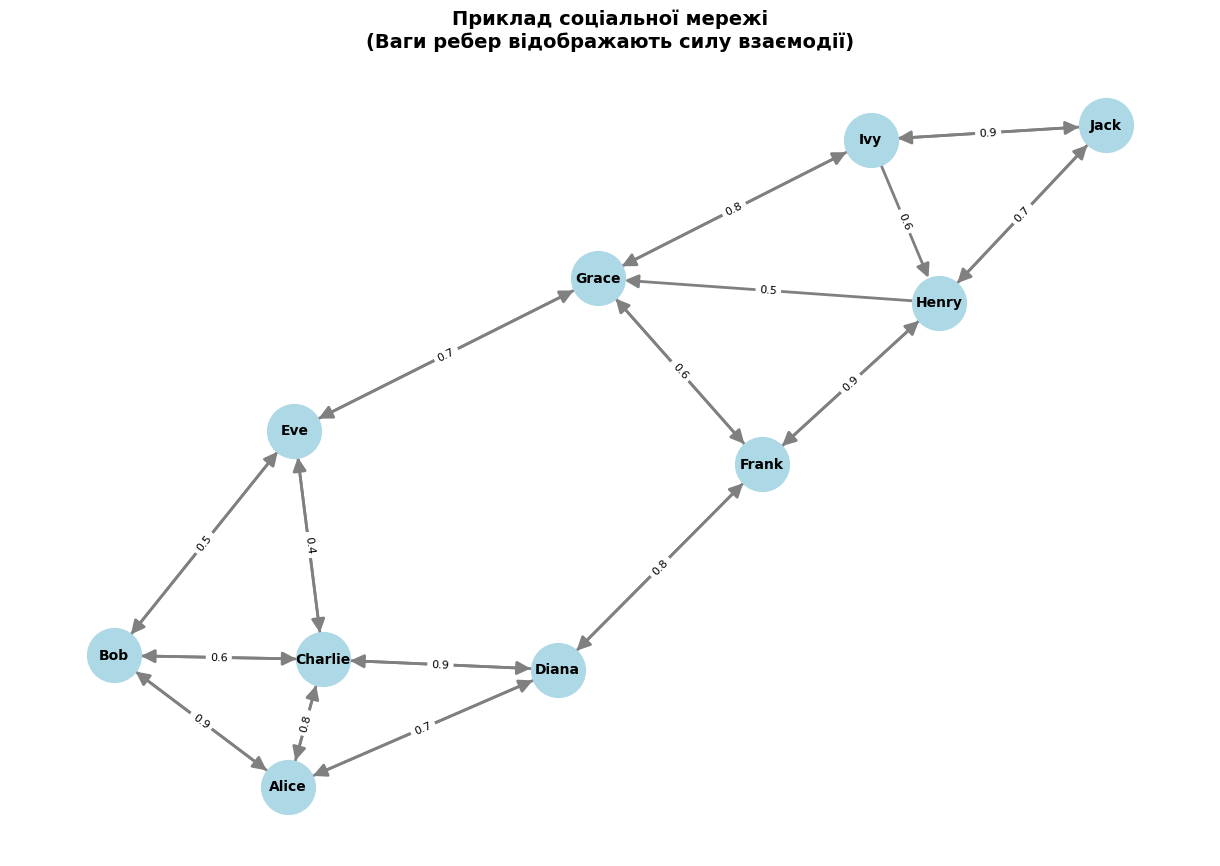

In [4]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(social_network)

nx.draw(social_network, pos, 
        with_labels=True, 
        node_color='lightblue', 
        node_size=1500, 
        font_size=10, 
        font_weight='bold',
        arrows=True,
        arrowsize=20,
        edge_color='gray',
        width=2)

edge_labels = nx.get_edge_attributes(social_network, 'weight')
nx.draw_networkx_edge_labels(social_network, pos, 
                            {k: f'{v:.1f}' for k, v in edge_labels.items()}, 
                            font_size=8)

plt.title('Приклад соціальної мережі\n(Ваги ребер відображають силу взаємодії)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


## 1. Пошук спільнот

### Пошук спільнот та алгоритм Louvain

**Мета**: Ідентифікувати групи вузлів, які більш щільно з'єднані внутрішньо, ніж зовнішньо.

**Застосування**: Аналіз соціальних мереж, кластеризація біологічних мереж, системи рекомендацій

Алгоритм Louvain - це жадібний метод оптимізації, який максимізує модулярність для знаходження спільнот у мережах.

**Формула модулярності**:
$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

Де:
- $A_{ij}$ - матриця суміжності
- $k_i$ - степінь вузла $i$
- $m$ - загальна кількість ребер
- $\delta(c_i, c_j)$ дорівнює 1, якщо вузли $i$ та $j$ в одній спільноті, інакше 0

**Кроки алгоритму**:
1. Почати з кожного вузла у власній спільноті
2. Для кожного вузла обчислити приріст модулярності від переміщення його до спільноти кожного сусіда
3. Перемістити вузол до спільноти, яка дає максимальний позитивний приріст
4. Повторювати до тих пір, поки не можливо покращення
5. Створити новий граф, де вузли - це знайдені спільноти
6. Повторити процес на новому графі

In [5]:
social_undirected = social_network.to_undirected()

import networkx.algorithms.community as nx_comm

communities = nx_comm.louvain_communities(social_undirected, weight='weight')

print("Результати виявлення спільнот:")
print(f"Кількість знайдених спільнот: {len(communities)}")
print("\nСпільноти:")
for i, community in enumerate(communities):
    print(f"Спільнота {i+1}: {list(community)}")

modularity = nx_comm.modularity(social_undirected, communities, weight='weight')
print(f"\nМодулярність: {modularity:.3f}")

Результати виявлення спільнот:
Кількість знайдених спільнот: 2

Спільноти:
Спільнота 1: ['Eve', 'Diana', 'Alice', 'Charlie', 'Bob']
Спільнота 2: ['Henry', 'Grace', 'Jack', 'Ivy', 'Frank']

Модулярність: 0.367


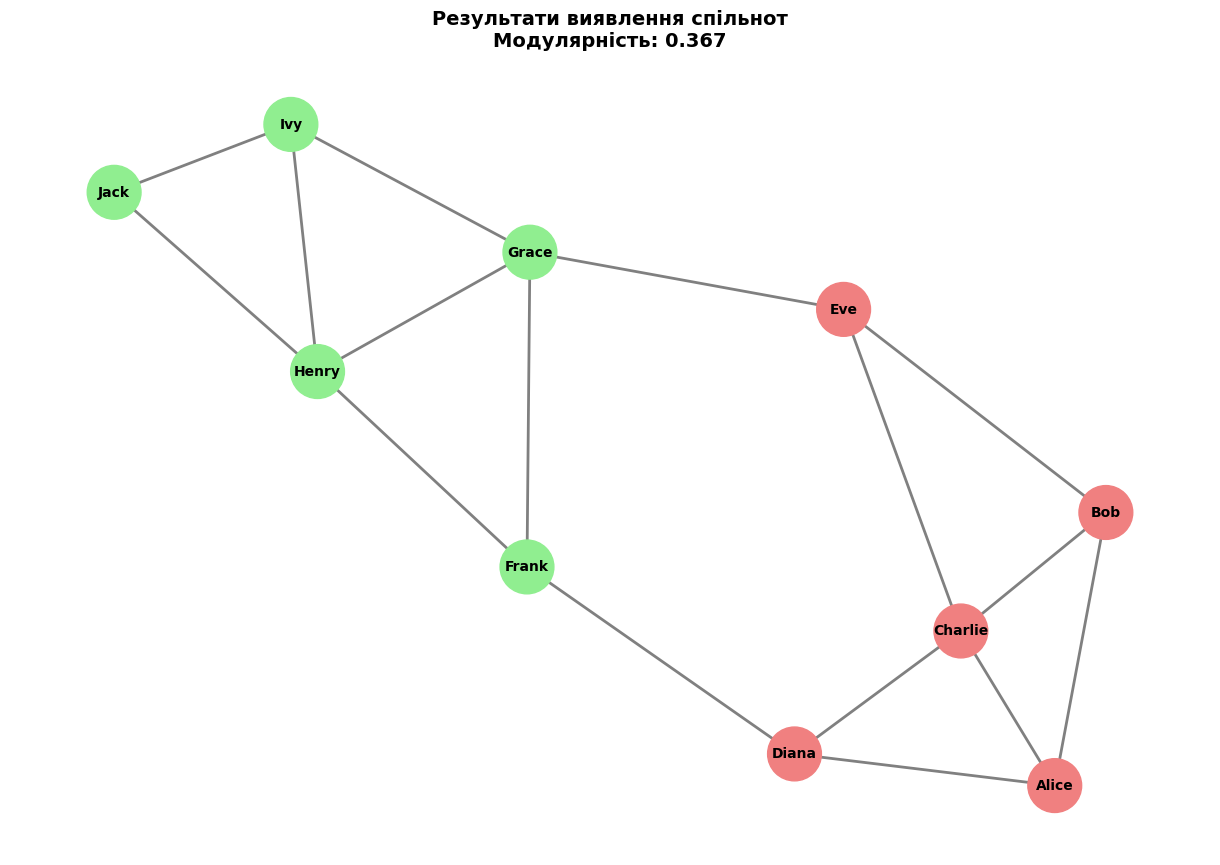

In [6]:
plt.figure(figsize=(12, 8))

colors = ['lightcoral', 'lightgreen', 'lightblue', 'lightyellow', 'lightpurple', 'lightbrown', 'lightpink', 'lightgray']
node_colors = ['white'] * social_undirected.number_of_nodes()

for i, community in enumerate(communities):
    color = colors[i % len(colors)]
    for node in community:
        node_idx = list(social_undirected.nodes()).index(node)
        node_colors[node_idx] = color

pos = nx.spring_layout(social_undirected)
nx.draw(
    social_undirected, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=1500,
    font_size=10,
    font_weight='bold',
    edge_color='gray',
    width=2
)

plt.title(f'Результати виявлення спільнот\nМодулярність: {modularity:.3f}',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Аналіз центральності

Центральність — це міра, яка дозволяє визначити, наскільки важливим або впливовим є певний вузол у мережі. Оцінка центральності допомагає знайти ключові вершини, що відіграють особливу роль у передачі інформації, координації, або контролі мережі.

Існують різні види центральності, кожен з яких підкреслює різний аспект "важливості" вузла:

- **Degree Centrality (центральність за степенем)** — визначає важливість вузла за кількістю його зв'язків із сусідами.
- **Betweenness Centrality (центральність за посередництвом)** — показує, наскільки часто вузол виступає посередником на найкоротших шляхах між іншими вузлами.
- **Closeness Centrality (центральність за близькістю)** — вимірює, наскільки вузол близький до всіх інших вузлів у мережі.
- **PageRank** — визначає важливість вузлів, враховуючи структуру зв'язків, ітеративно передаючи "вагу" через мережу.

### Алгоритм PageRank

**Мета**: Ідентифікувати найважливіші або найвпливовіші вузли в мережі, враховуючи не лише кількість вхідних зв'язків, а й їхню "вагу" (важливість вузлів, що посилаються).

**Застосування**: Аналіз соціального впливу, стійкість мережі, аналіз потоку інформації, ранжування веб-сторінок.

PageRank — це алгоритм, який вимірює важливість вузлів в орієнтованому графі, розроблений для ранжування веб-сторінок.

**Формула PageRank**:
$$
PR(A) = \frac{1-d}{N} + d \sum_{B \in M(A)} \frac{PR(B)}{L(B)}
$$

Де:
- $PR(A)$ — PageRank сторінки A
- $d$ — коефіцієнт затухання (зазвичай 0.85)
- $N$ — загальна кількість сторінок
- $M(A)$ — множина сторінок, які посилаються на A
- $L(B)$ — кількість вихідних посилань зі сторінки B

**Кроки алгоритму**:
1. Ініціалізувати всі вузли з рівними значеннями PageRank
2. Ітеративно оновлювати значення PageRank, використовуючи формулу
3. Продовжувати до збіжності (значення стабілізуються)

In [7]:
pagerank_scores = nx.pagerank(social_network, weight='weight')

sorted_pagerank = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)

print("Результати аналізу PageRank:")
print("=" * 40)
for i, (node, score) in enumerate(sorted_pagerank, 1):
    print(f"{i:2d}. {node:8s}: {score:.4f}")

degree_centrality = nx.degree_centrality(social_network)
betweenness_centrality = nx.betweenness_centrality(social_network, weight='weight')
closeness_centrality = nx.closeness_centrality(social_network, distance='weight')

centrality_df = pd.DataFrame({
    'Вузол': list(social_network.nodes()),
    'PageRank': [pagerank_scores[node] for node in social_network.nodes()],
    'Степінь': [degree_centrality[node] for node in social_network.nodes()],
    'Посередництво': [betweenness_centrality[node] for node in social_network.nodes()],
    'Близькість': [closeness_centrality[node] for node in social_network.nodes()]
})

print("\nПорівняння центральностей:")
print(centrality_df.round(4))

Результати аналізу PageRank:
 1. Charlie : 0.1229
 2. Grace   : 0.1155
 3. Alice   : 0.1095
 4. Frank   : 0.1094
 5. Diana   : 0.1093
 6. Henry   : 0.0970
 7. Bob     : 0.0953
 8. Ivy     : 0.0865
 9. Eve     : 0.0834
10. Jack    : 0.0713

Порівняння центральностей:
     Вузол  PageRank  Степінь  Посередництво  Близькість
0    Alice    0.1095   0.6667         0.0000      0.5921
1      Bob    0.0953   0.6667         0.0000      0.7143
2  Charlie    0.1229   0.8889         0.1597      0.7965
3    Diana    0.1093   0.6667         0.0694      0.6977
4      Eve    0.0834   0.6667         0.3472      0.9000
5    Frank    0.1094   0.6667         0.1458      0.7759
6    Grace    0.1155   0.7778         0.4444      0.9574
7    Henry    0.0970   0.6667         0.1389      0.6040
8      Ivy    0.0865   0.5556         0.1111      0.6122
9     Jack    0.0713   0.4444         0.0000      0.4865


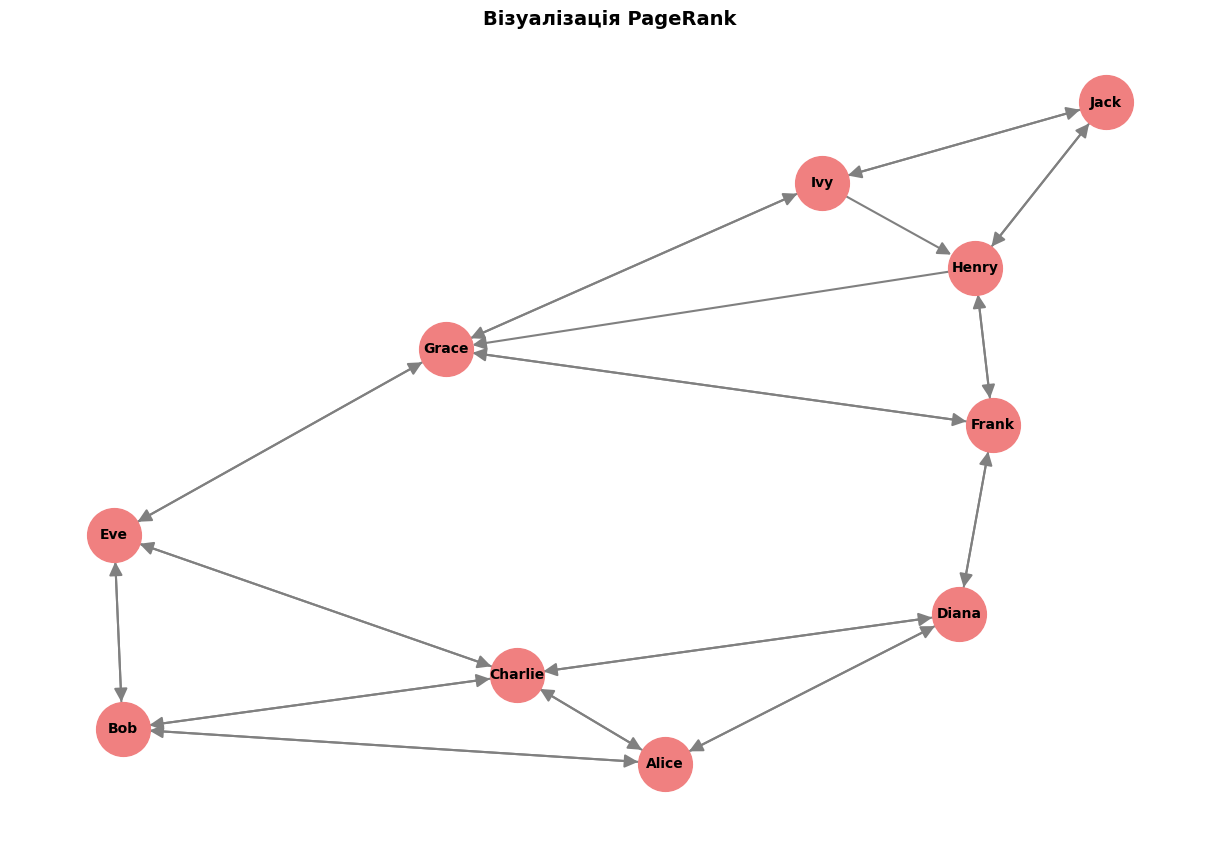

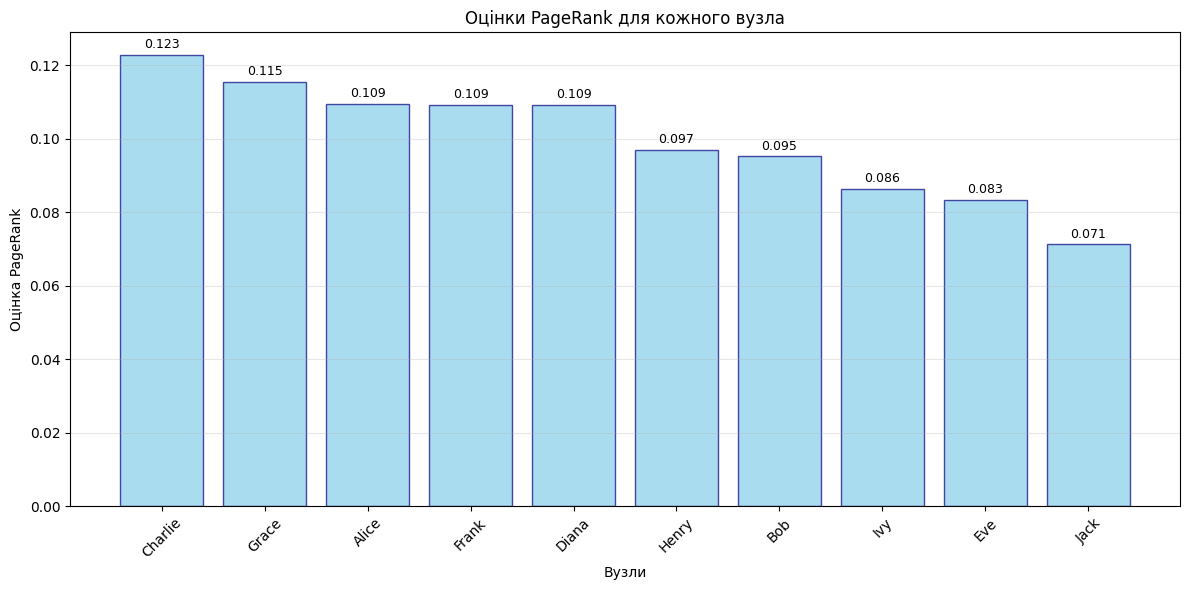

In [8]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(social_network, seed=10)
nx.draw(social_network, pos, 
        with_labels=True, 
        node_color='lightcoral', 
        node_size=1500, 
        font_size=10, 
        font_weight='bold',
        arrows=True,
        arrowsize=20,
        edge_color='gray',
        width=1.5)

plt.title('Візуалізація PageRank', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
nodes = [item[0] for item in sorted_pagerank]
scores = [item[1] for item in sorted_pagerank]

bars = plt.bar(range(len(nodes)), scores, color='skyblue', edgecolor='navy', alpha=0.7)
plt.xlabel('Вузли')
plt.ylabel('Оцінка PageRank')
plt.title('Оцінки PageRank для кожного вузла')
plt.xticks(range(len(nodes)), nodes, rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, (bar, score) in enumerate(zip(bars, scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 3. Прогнозування зв'язків

### Спільні сусіди з коефіцієнтом Жаккара

**Мета**: Прогнозувати відсутні або майбутні зв'язки між вузлами.

**Застосування**: Системи рекомендацій, прогнозування взаємодії білків, зростання соціальних мереж

Цей метод прогнозує зв'язки на основі схожості околиць вузлів.

**Коефіцієнт Жаккара**:
$$J(A,B) = \frac{|N(A) \cap N(B)|}{|N(A) \cup N(B)|}$$

Де $N(A)$ - множина сусідів вузла A.

**Оцінка**:
$$score(A,B) = |N(A) \cap N(B)| \times J(A,B)$$

Алгоритм працює так:
1. Для кожної пари нез'єднаних вузлів обчислити кількість спільних сусідів
2. Обчислити коефіцієнт Жаккара для вимірювання схожості околиць вузлів
3. Поєднати ці міри для отримання оцінки прогнозування
4. Ранжувати всі можливі зв'язки за їх оцінками прогнозування

In [9]:
def jaccard_coefficient(graph, u, v):
    neighbors_u = set(graph.neighbors(u))
    neighbors_v = set(graph.neighbors(v))
    
    intersection = len(neighbors_u.intersection(neighbors_v))
    union = len(neighbors_u.union(neighbors_v))
    
    if union == 0:
        return 0
    return intersection / union

def common_neighbors_score(graph, u, v):
    neighbors_u = set(graph.neighbors(u))
    neighbors_v = set(graph.neighbors(v))
    return len(neighbors_u.intersection(neighbors_v))

def link_prediction_score(graph, u, v):
    cn_score = common_neighbors_score(graph, u, v)
    jc_score = jaccard_coefficient(graph, u, v)
    return cn_score * jc_score

social_undirected = social_network.to_undirected()

all_pairs = []
for u in social_undirected.nodes():
    for v in social_undirected.nodes():
        if u != v and not social_undirected.has_edge(u, v):
            all_pairs.append((u, v))

prediction_scores = []
for u, v in all_pairs:
    score = link_prediction_score(social_undirected, u, v)
    cn = common_neighbors_score(social_undirected, u, v)
    jc = jaccard_coefficient(social_undirected, u, v)
    prediction_scores.append((u, v, score, cn, jc))

prediction_scores.sort(key=lambda x: x[2], reverse=True)

print("Результати прогнозування зв'язків:")
print("=" * 80)
print(f"{'Ранг':<4} {'Вузол 1':<8} {'Вузол 2':<8} {'Оцінка':<8} {'Спільні сусіди':<16} {'Коеф. Жаккара':<12}")
print("-" * 80)

for i, (u, v, score, cn, jc) in enumerate(prediction_scores[:10], 1):
    print(f"{i:<4} {u:<8} {v:<8} {score:<8.3f} {cn:<16} {jc:<12.3f}")

print(f"\nВсього можливих нових зв'язків: {len(prediction_scores)}")
print(f"Топ 5 найбільш ймовірних зв'язків:")
for i, (u, v, score, cn, jc) in enumerate(prediction_scores[:5], 1):
    print(f"{i}. {u} - {v} (Оцінка: {score:.3f})")

Результати прогнозування зв'язків:
Ранг Вузол 1  Вузол 2  Оцінка   Спільні сусіди   Коеф. Жаккара
--------------------------------------------------------------------------------
1    Alice    Eve      1.000    2                0.500       
2    Bob      Diana    1.000    2                0.500       
3    Diana    Bob      1.000    2                0.500       
4    Eve      Alice    1.000    2                0.500       
5    Frank    Ivy      1.000    2                0.500       
6    Grace    Jack     1.000    2                0.500       
7    Ivy      Frank    1.000    2                0.500       
8    Jack     Grace    1.000    2                0.500       
9    Frank    Jack     0.250    1                0.250       
10   Jack     Frank    0.250    1                0.250       

Всього можливих нових зв'язків: 58
Топ 5 найбільш ймовірних зв'язків:
1. Alice - Eve (Оцінка: 1.000)
2. Bob - Diana (Оцінка: 1.000)
3. Diana - Bob (Оцінка: 1.000)
4. Eve - Alice (Оцінка: 1.000)
5. Fra

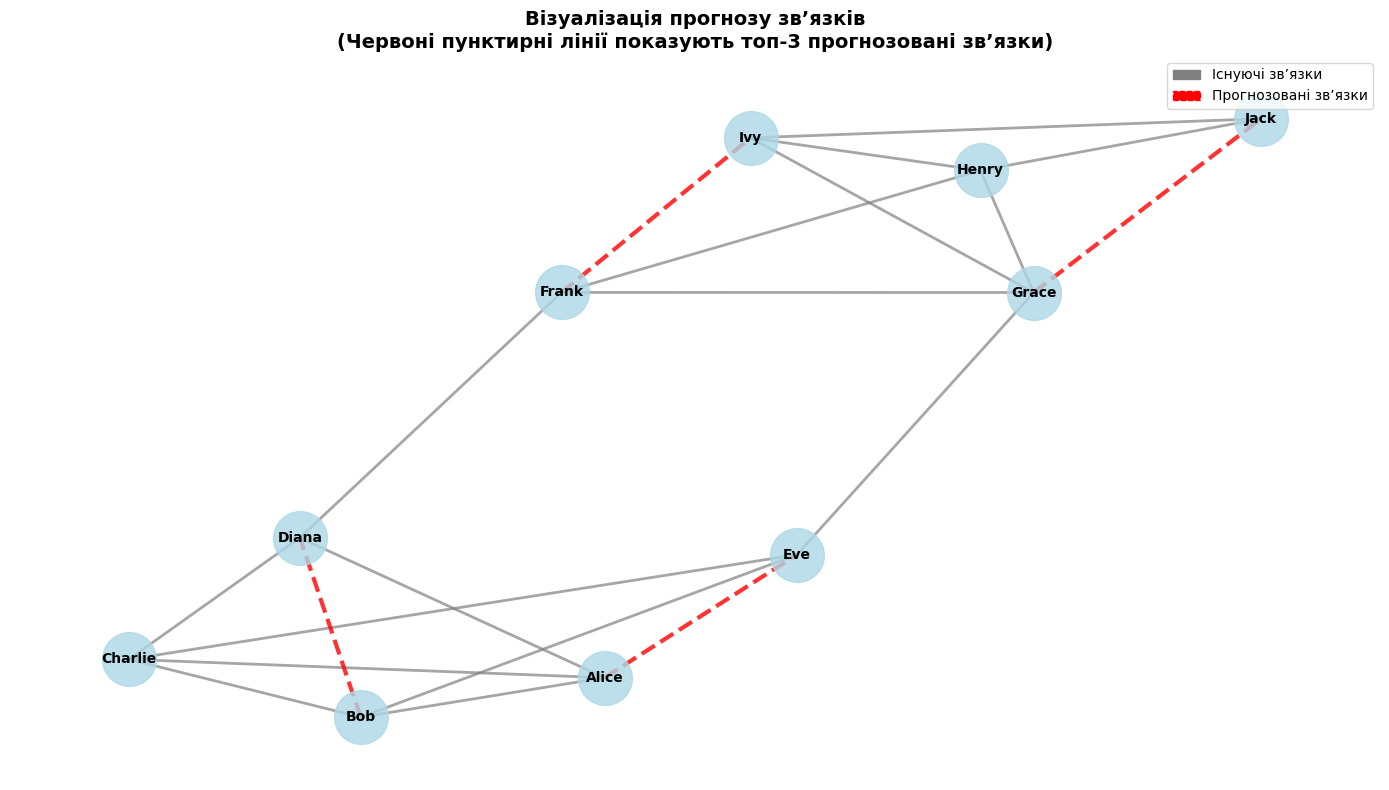

In [10]:
plt.figure(figsize=(14, 8))

G_viz = social_undirected.copy()

top_predictions = [(u, v, score, cn, jc) for u, v, score, cn, jc in prediction_scores if score > 0.8]
for u, v, score, cn, jc in top_predictions:
    G_viz.add_edge(u, v, predicted=True, score=score)

existing_edges = [(u, v) for u, v in G_viz.edges() if not G_viz[u][v].get('predicted', False)]
predicted_edges = [(u, v) for u, v in G_viz.edges() if G_viz[u][v].get('predicted', False)]

pos = nx.spring_layout(G_viz)

nx.draw_networkx_edges(G_viz, pos, edgelist=existing_edges, 
                      edge_color='gray', width=2, alpha=0.7)

nx.draw_networkx_edges(G_viz, pos, edgelist=predicted_edges, 
                      edge_color='red', width=3, alpha=0.8, style='dashed')

nx.draw_networkx_nodes(G_viz, pos, node_color='lightblue', 
                      node_size=1500, alpha=0.8)

nx.draw_networkx_labels(G_viz, pos, font_size=10, font_weight='bold')

import matplotlib.patches as mpatches
existing_patch = mpatches.Patch(color='gray', label='Існуючі звʼязки')
predicted_patch = mpatches.Patch(color='red', linestyle='--', label='Прогнозовані звʼязки')
plt.legend(handles=[existing_patch, predicted_patch], loc='upper right')

plt.title('Візуалізація прогнозу звʼязків\n(Червоні пунктирні лінії показують топ-3 прогнозовані звʼязки)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Кластеризація графів

### Спектральна кластеризація

**Мета**: Розбити вузли на групи на основі структурної схожості.

**Застосування**: Аналіз мереж, організація даних, виявлення аномалій

Спектральна кластеризація використовує власні значення та власні вектори лапласіана графа для виконання кластеризації.

**Лапласіан графа**:
$$L = D - A$$

Де $D$ - матриця степенів, а $A$ - матриця суміжності.

**Кроки алгоритму**:
1. Обчислити лапласіан графа
2. Знайти $k$ найменших власних значень та їх власні вектори
3. Використати власні вектори як ознаки для кластеризації k-means

**Чому це працює**: Власні вектори лапласіана захоплюють структуру графа, причому перші кілька власних векторів відповідають найбільш значущим розрізам у графі.

In [11]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

adjacency_matrix = nx.adjacency_matrix(social_undirected, weight='weight').toarray()

n_clusters_range = range(2, 6)
spectral_results = {}

for n_clusters in n_clusters_range:
    spectral = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
    cluster_labels = spectral.fit_predict(adjacency_matrix)
    spectral_results[n_clusters] = cluster_labels
    print(f"Спектральна кластеризація для {n_clusters} кластерів:")
    print(f"Призначення по кластерам: {cluster_labels}")
    clusters = {}
    for i, label in enumerate(cluster_labels):
        if label not in clusters:
            clusters[label] = []
        clusters[label].append(list(social_undirected.nodes())[i])
    for cluster_id, nodes in clusters.items():
        print(f"  Кластер {cluster_id}: {nodes}")
    print()

best_n_clusters = 3
best_labels = spectral_results[best_n_clusters]

print(f"Використовуємо {best_n_clusters} кластери для візуалізації:")
print(f"Призначення по кластерам: {best_labels}")

clusters = {}
for i, label in enumerate(best_labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(list(social_undirected.nodes())[i])

for cluster_id, nodes in clusters.items():
    print(f"Кластер {cluster_id}: {nodes}")

Спектральна кластеризація для 2 кластерів:
Призначення по кластерам: [0 0 0 0 0 1 1 1 1 1]
  Кластер 0: ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve']
  Кластер 1: ['Frank', 'Grace', 'Henry', 'Ivy', 'Jack']

Спектральна кластеризація для 3 кластерів:
Призначення по кластерам: [0 0 0 2 0 2 1 1 1 1]
  Кластер 0: ['Alice', 'Bob', 'Charlie', 'Eve']
  Кластер 2: ['Diana', 'Frank']
  Кластер 1: ['Grace', 'Henry', 'Ivy', 'Jack']

Спектральна кластеризація для 4 кластерів:
Призначення по кластерам: [0 0 0 3 2 3 2 1 1 1]
  Кластер 0: ['Alice', 'Bob', 'Charlie']
  Кластер 3: ['Diana', 'Frank']
  Кластер 2: ['Eve', 'Grace']
  Кластер 1: ['Henry', 'Ivy', 'Jack']

Спектральна кластеризація для 5 кластерів:
Призначення по кластерам: [4 4 0 0 2 1 2 1 3 3]
  Кластер 4: ['Alice', 'Bob']
  Кластер 0: ['Charlie', 'Diana']
  Кластер 2: ['Eve', 'Grace']
  Кластер 1: ['Frank', 'Henry']
  Кластер 3: ['Ivy', 'Jack']

Використовуємо 3 кластери для візуалізації:
Призначення по кластерам: [0 0 0 2 0 2 1 1 1 1]
Клас

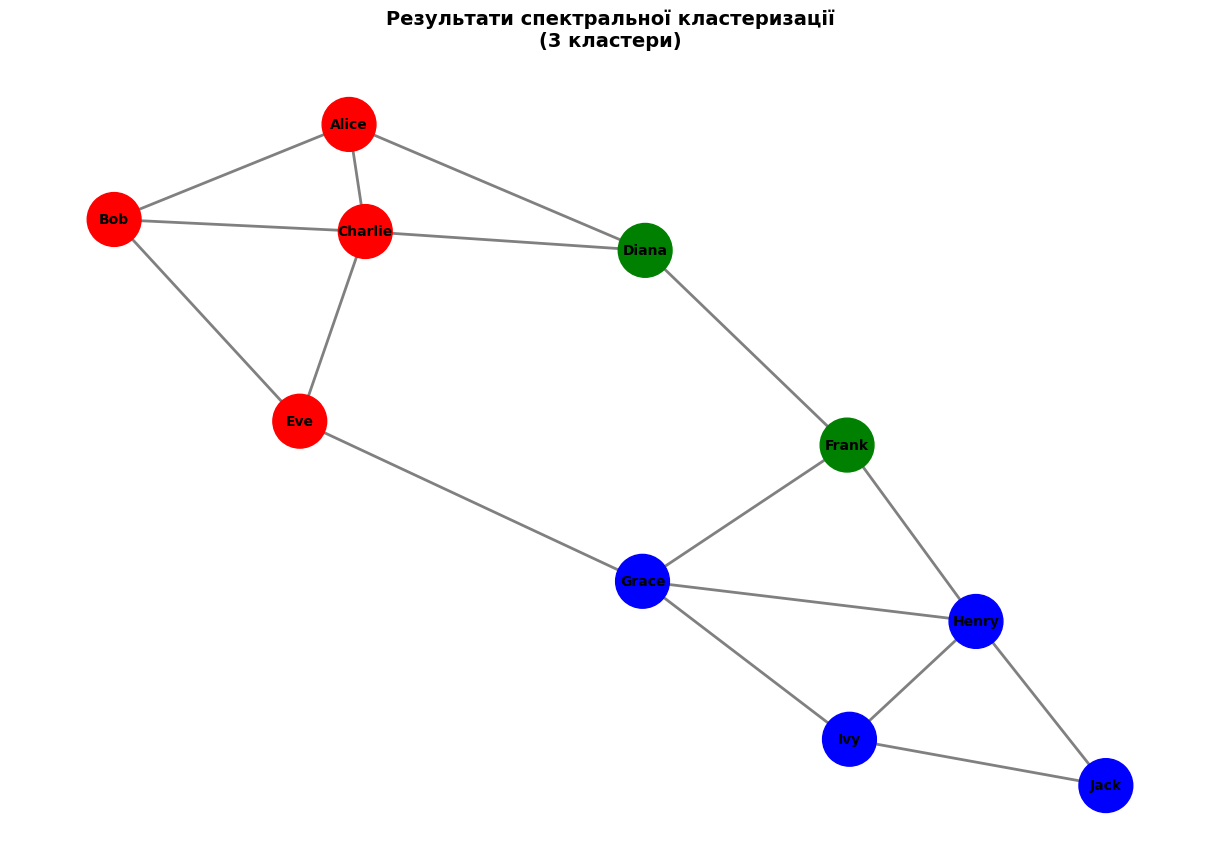


Порівняння з алгоритмом Louvain:
Мітки спектральної кластеризації: [0 0 0 2 0 2 1 1 1 1]
Мітки алгоритму Louvain:           [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

Метрики подібності:
Індекс Ранда: 0.580
Нормалізована взаємна інформація: 0.634


In [12]:
plt.figure(figsize=(12, 8))

colors = ['red', 'blue', 'green', 'orange', 'purple']
node_colors = ['white'] * social_undirected.number_of_nodes()

for i, label in enumerate(best_labels):
    color = colors[label % len(colors)]
    node_colors[i] = color

pos = nx.spring_layout(social_undirected)
nx.draw(social_undirected, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=1500, 
        font_size=10, 
        font_weight='bold',
        edge_color='gray',
        width=2)

plt.title(f'Результати спектральної кластеризації\n({best_n_clusters} кластери)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\nПорівняння з алгоритмом Louvain:")
print("=" * 50)

louvain_labels = [-1] * len(social_undirected.nodes())
for i, node in enumerate(social_undirected.nodes()):
    for j, community in enumerate(communities):
        if node in community:
            louvain_labels[i] = j
            break

print(f"Мітки спектральної кластеризації: {best_labels}")
print(f"Мітки алгоритму Louvain:           {louvain_labels}")

ari_score = adjusted_rand_score(best_labels, louvain_labels)
nmi_score = normalized_mutual_info_score(best_labels, louvain_labels)

print(f"\nМетрики подібності:")
print(f"Індекс Ранда: {ari_score:.3f}")
print(f"Нормалізована взаємна інформація: {nmi_score:.3f}")